In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearnex import patch_sklearn
import os
import scipy.ndimage as ndimage
import skimage
from tqdm import tqdm
import glob
from skimage.io import imread
import scipy.ndimage as ndi
import multiprocessing
from scipy.ndimage import distance_transform_edt
from scipy.spatial.distance import cdist
from skimage.measure import regionprops,regionprops_table

In [2]:
input_dir = "../../Img_Denoised/contrast_adj/"
fiber_channel_name = 'Collage-Type_I'
biosamples_path = '/home/giuseppe/devices/Delta_Tissue/IMC/IMC_data/ExtraDocs/processed_response_RCB.csv'
biosamples =pd.read_csv(biosamples_path)


In [3]:
tb = pd.DataFrame(os.listdir(input_dir),columns = ['fov'])
tb['Leap_ID'] = tb.fov.str.split('_',n = 1).str[0]
biosamples['LEAP_ID'] = biosamples.LEAP_ID.str.capitalize()
tb = tb.merge(biosamples,left_on='Leap_ID', right_on='LEAP_ID')


In [73]:
len(list(map(lambda x: x.replace('.tiff',''),os.listdir(os.path.join(input_dir,acq)))))

38

In [27]:
tb_carbo

,fov,Leap_ID,LEAP_ID,SLIDE_NUMBER,BIOBANK_ID,SAMPLE_TYPE_(CORE/RESECTION),FORMAT_(FFPE/FROZEN),FORCE_TRIAL?_(Y/N),DATE_SECTIONED,H&E_NOTES,...,COMMENTS,new_Response,Patient,Stain,Keep,extreme_non_responder,RCB_Group,NACT_treatment _group,RC_scores,diagnosis_year
0,Leap081_8,Leap081,Leap081,35.0,18000527-IncT FPE-2,RESECTION,FFPE,NaN,2023-02-06 00:00:00,NaN,...,RESECTION,nR,57,4,y,NaN,2.0,EC-T-carbo,1.694,2017.0
5,Leap045_11,Leap045,Leap045,20.0,19005866-IncT FPE-1,RESECTION,FFPE,NaN,2022-11-08 00:00:00,NaN,...,RESECTION,nR,30,4,y,NaN,2.0,EC-T-carbo,2.415,2018.0
13,Leap081_1,Leap081,Leap081,35.0,18000527-IncT FPE-2,RESECTION,FFPE,NaN,2023-02-06 00:00:00,NaN,...,RESECTION,nR,57,4,y,NaN,2.0,EC-T-carbo,1.694,2017.0
41,Leap006_4,Leap006,Leap006,3.0,20000728-IncT FPE-1,RESECTION,FFPE,NaN,21/06/2022,NaN,...,RESECTION,nR,3,1,y,NaN,2.0,EC-T-carbo,1.865,2019.0
58,Leap002_4,Leap002,Leap002,1.0,20001982-IncT FPE-1,RESECTION,FFPE,NaN,21/06/2022,NaN,...,RESECTION,nR,1,1,y,NaN,3.0,EC-T-carbo,3.750,2019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,Leap016_4,Leap016,Leap016,7.0,18000628-IncT FPE-1,RESECTION,FFPE,NaN,28/06/2022,NaN,...,RESECTION,enR,11,2,y,v,3.0,EC-T-carbo,4.419,2017.0
628,Leap081_5,Leap081,Leap081,35.0,18000527-IncT FPE-2,RESECTION,FFPE,NaN,2023-02-06 00:00:00,NaN,...,RESECTION,nR,57,4,y,NaN,2.0,EC-T-carbo,1.694,2017.0
630,Leap045_10,Leap045,Leap045,20.0,19005866-IncT FPE-1,RESECTION,FFPE,NaN,2022-11-08 00:00:00,NaN,...,RESECTION,nR,30,4,y,NaN,2.0,EC-T-carbo,2.415,2018.0
639,Leap081_2,Leap081,Leap081,35.0,18000527-IncT FPE-2,RESECTION,FFPE,NaN,2023-02-06 00:00:00,NaN,...,RESECTION,nR,57,4,y,NaN,2.0,EC-T-carbo,1.694,2017.0


In [28]:
smoothing_factor = 1
results = []
cond = (tb['SAMPLE_TYPE_(CORE/RESECTION)'] == 'RESECTION')*(tb['NACT_treatment _group'].str.contains('carbo').fillna(False))
tb_carbo = tb[cond]
def process_acq(acq):
    carboplatin = skimage.io.imread(os.path.join(input_dir,acq,'Carboplatin.tiff'))
    thr = 0.
    carboplatin = ndimage.gaussian_filter(carboplatin,sigma = smoothing_factor)
    marker_set = list(map(lambda x: x.replace('.tiff',''),os.listdir(os.path.join(input_dir,acq))))
    marker_set.remove('Carboplatin')
    cond = carboplatin>thr
    if np.any(cond):
        img_out_stack = np.zeros((len(marker_set)+1,np.count_nonzero(cond)))
        img_out_stack[0] = carboplatin[cond]
        for ind,marker in enumerate(marker_set):
            img = skimage.io.imread(os.path.join(input_dir,acq,marker+'.tiff'))
            img = ndimage.gaussian_filter(img,sigma = smoothing_factor)
            img_out_stack[ind+1] = img[cond]
        return np.corrcoef(img_out_stack)
    else:
        #if empty carboplatin
        pass
pool = multiprocessing.Pool()
results= pool.map(process_acq,tb_carbo.fov)
results =[el for el in results if el is not None]
marker_set = list(map(lambda x: x.replace('.tiff',''),os.listdir(os.path.join(input_dir,'Leap001_8'))))
marker_set.remove('Carboplatin')

/tmp/ipykernel_45827/3220603676.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cond = (tb['SAMPLE_TYPE_(CORE/RESECTION)'] == 'RESECTION')*(tb['NACT_treatment _group'].str.contains('carbo').fillna(False))


In [29]:
corr = np.mean(results,axis = 0 )
corr_pd =pd.DataFrame(corr,index = ['Carboplatin']+marker_set,columns=['Carboplatin']+marker_set)

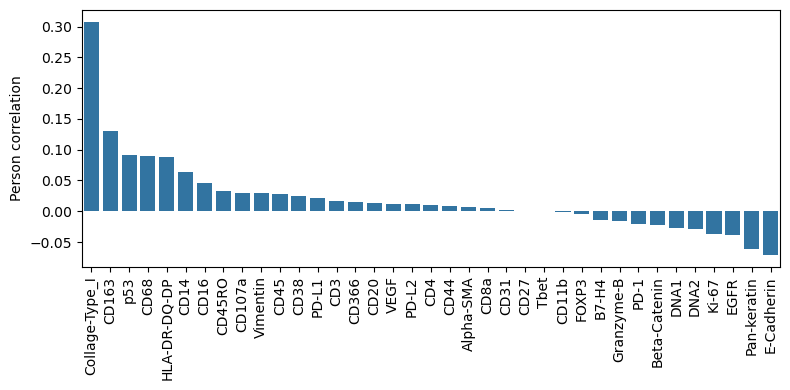

In [30]:

plt.figure(figsize = (8,4))
sns.barplot(data = corr_pd.Carboplatin.drop('Carboplatin').sort_values(ascending=False)[:],orient='v')
_ =plt.xticks(rotation = 90,ha= 'center')
#plt.title('Marker correlation with Carboplatin')
plt.ylabel('Person correlation')
plt.xlabel('')
plt.tight_layout()
#plt.savefig(fig_out_folder+'carboplatin_corr.png')

In [34]:
acq = tb_carbo.fov.iloc[2]
carboplatin = skimage.io.imread(os.path.join(input_dir,acq,'Carboplatin.tiff'))


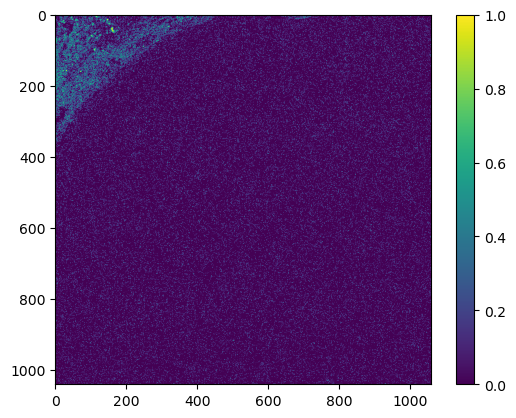

In [35]:
plt.imshow(carboplatin)
plt.colorbar()

['../../Img_Denoised/contrast_adj/Leap002_6/Carboplatin.tiff',
 '../../Img_Denoised/contrast_adj/Leap002_6/DNA1.tiff',
 '../../Img_Denoised/contrast_adj/Leap002_6/DNA2.tiff',
 '../../Img_Denoised/contrast_adj/Leap002_6/Collage-Type_I.tiff']

/tmp/ipykernel_75378/974114605.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = plt.cm.get_cmap(cmap_name)


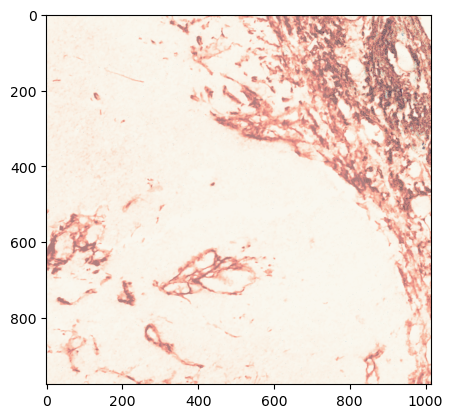

In [134]:
gain = 3
def blend_images(imgs,cmaps,dna_imgs,dna_cmap = 'Greens'):
    output = np.zeros((*np.shape(imgs[0]),4))
    weight = 1/len(imgs)
    for img, cmap_name in zip(imgs,cmaps):
        colormap = plt.cm.get_cmap(cmap_name)
        img_c = colormap(img)
        img_c[:,:,-1]=1#*(1+np.tanh(gain*img))/2
        output+=img_c*weight
    '''
    for img in dna_imgs:
        colormap = plt.cm.get_cmap(dna_cmap)
        img_c = colormap(img)
        img_c[:,:,-1]=0.9*(1+np.tanh(gain*img))/2
        output+=img_c*weight
     '''
    return output
paths = [os.path.join(input_dir,acq,marker+'.tiff') for marker in ['Carboplatin',fiber_channel_name]]
imgs = skimage.io.imread_collection(paths)
dna_imgs = skimage.io.imread_collection([os.path.join(input_dir,acq,marker+'.tiff') for marker in ['DNA1','DNA2']])
plt.imshow(blend_images(imgs[:2],['GnBu','Reds'][:2],dna_imgs))

/tmp/ipykernel_75378/1378585408.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  skimage.io.imshow(plt.cm.get_cmap('Blues')(carboplatin))


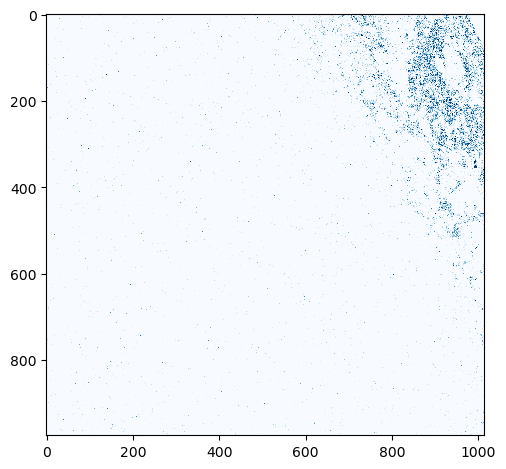

In [150]:
skimage.io.imshow(plt.cm.get_cmap('Blues')(carboplatin))

In [108]:
a = colormap(collagen)
((1+np.tanh(collagen))/2).max()
collagen.max()

1.0

In [45]:
skimage.io.imread_collection?

Signature:
skimage.io.imread_collection(
    load_pattern,
    conserve_memory=True,
    plugin=None,
    **plugin_args,
)
Docstring:
Load a collection of images.

Parameters
----------
load_pattern : str or list
    List of objects to load. These are usually filenames, but may
    vary depending on the currently active plugin.  See the docstring
    for ``ImageCollection`` for the default behaviour of this parameter.
conserve_memory : bool, optional
    If True, never keep more than one in memory at a specific
    time.  Otherwise, images will be cached once they are loaded.

Returns
-------
ic : ImageCollection
    Collection of images.

Other Parameters
----------------
plugin_args : keywords
    Passed to the given plugin.
File:      ~/anaconda3/lib/python3.9/site-packages/skimage/io/_io.py
Type:      function

/tmp/ipykernel_75378/3933505607.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = plt.cm.get_cmap('Blues')


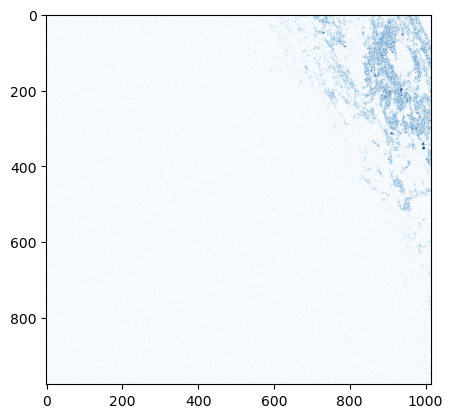

In [43]:
carboplatin = skimage.io.imread(os.path.join(input_dir,'Leap002_6','Carboplatin.tiff'))

colormap = plt.cm.get_cmap('Blues')
plt.imshow(colormap(carboplatin))

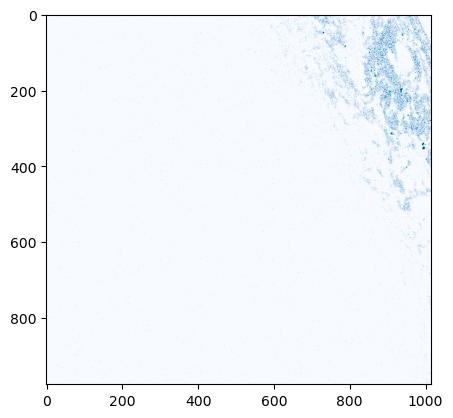

In [48]:
acq = 'Leap002_6'
plt.imshow(carboplatin,cmap = 'Blues')
collagen = skimage.io.imread(os.path.join(input_dir,acq,fiber_channel_name+'.tiff'))
#plt.imshow(collagen,cmap = 'Reds',alpha = 0.5)
dna =    skimage.io.imread(os.path.join(input_dir,acq,'DNA1.tiff'))
#plt.imshow(dna,cmap = 'Greens',alpha = 0.1)


0.13867188

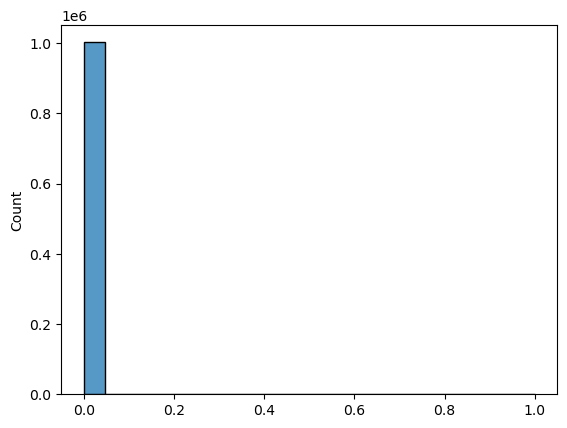

In [28]:
sns.histplot(carboplatin.reshape(-1))
skimage.filters.threshold_otsu(carboplatin)

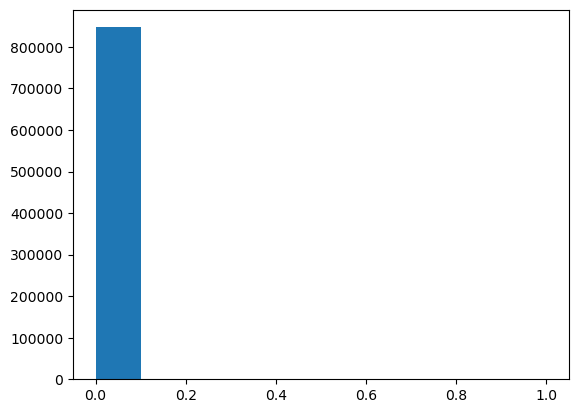

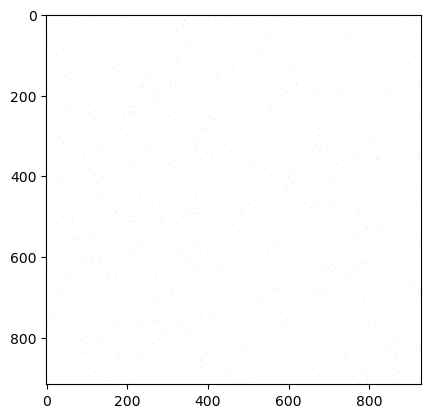

In [119]:
plt.hist(carboplatin.reshape(-1))
plt.figure()
fg_thr = skimage.filters.threshold_otsu(carboplatin)#foreground threshold

mask = carboplatin>fg_thr
plt.imshow(mask,cmap = 'Greys')

0.15039062